In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config as cfg

df = pd.read_csv(f"{cfg.RESULTS_DIR}/synthetic_results_wrong_copula.csv")

df.groupby(["dgp_copula", "true_k_tau"], as_index=False).agg(
    alpha_c_mult=("alpha_c_mult", "first"),
    censoring_rate=("censoring_rate", "mean"),
)

,dgp_copula,true_k_tau,alpha_c_mult,censoring_rate
0,clayton,0.0,0.728814,0.62516
1,clayton,0.1,0.728814,0.62683
2,clayton,0.2,0.728814,0.63139
3,clayton,0.3,1.110169,0.28075
4,clayton,0.4,0.728814,0.63781
5,clayton,0.5,1.135593,0.24880
6,clayton,0.6,1.135593,0.24271
7,clayton,0.7,1.110169,0.25828
8,clayton,0.8,1.110169,0.25042
9,frank,0.0,0.728814,0.62375


family         180
dep_clayton     90
dep_frank       90
gaussian        90
Name: experiment, dtype: int64
Index(['experiment', 'seed', 'dgp_copula', 'true_k_tau', 'assumed_copula',
       'assumed_k_tau', 'tau_abs_error', 'alpha_c_mult', 'alpha_c_used',
       'censoring_rate', 'ibs_true', 'ibs_ipcw', 'ibs_dep_bguw', 'err_ipcw',
       'err_dep_bguw'],
      dtype='object')


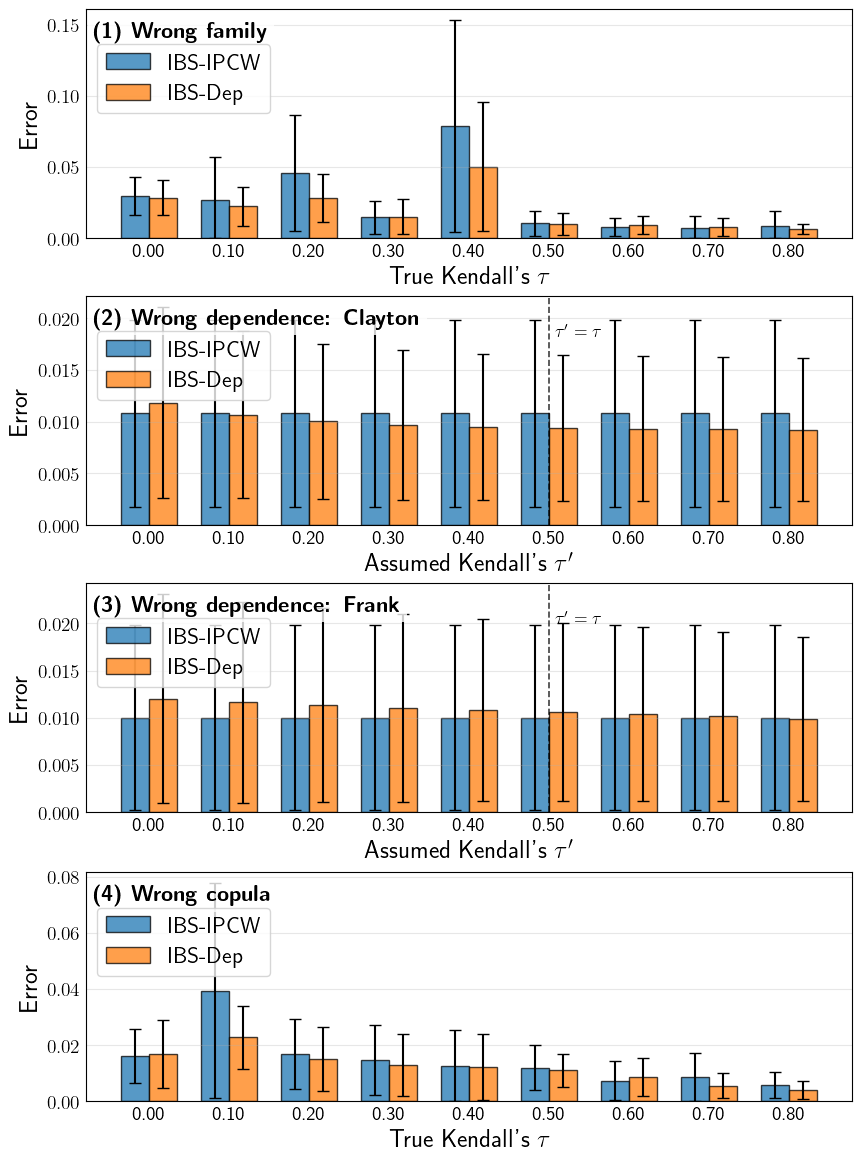

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config as cfg

# --- Matplotlib style ---
plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}"
})

# --- Load data ---
filename = f"{cfg.RESULTS_DIR}/synthetic_results_wrong_copula.csv"
df = pd.read_csv(filename)

print(df["experiment"].value_counts())
print(df.columns)

# New experiment layout:
# family       = wrong family, averaged over Clayton/Frank within seed
# dep_clayton = true Clayton tau=0.5, assumed Clayton tau' varied
# dep_frank   = true Frank tau=0.5, assumed Frank tau' varied
# gaussian    = Gaussian DGP, evaluated with Clayton
keep_exps = ["family", "dep_clayton", "dep_frank", "gaussian"]
dfp = df[df["experiment"].isin(keep_exps)].copy()

# Use assumed_k_tau for the dependence-strength panels.
# Use true_k_tau for family/gaussian panels.
dfp["plot_tau"] = np.where(
    dfp["experiment"].isin(["dep_clayton", "dep_frank"]),
    dfp["assumed_k_tau"],
    dfp["true_k_tau"],
)

# Step 1: average over DGP copulas within seed where relevant.
# For family: average Clayton/Frank within seed.
# For dep_clayton/dep_frank: no averaging across copula family.
# For gaussian: only Gaussian DGP.
seed_level = (
    dfp.groupby(["experiment", "plot_tau", "seed"], as_index=False)
       .agg(
           err_ipcw=("err_ipcw", "mean"),
           err_dep_bguw=("err_dep_bguw", "mean"),
       )
)

# Step 2: mean/std across seeds
agg = (
    seed_level.groupby(["experiment", "plot_tau"], as_index=False)
              .agg(
                  ipcw_mean=("err_ipcw", "mean"),
                  ipcw_std=("err_ipcw", "std"),
                  dep_mean=("err_dep_bguw", "mean"),
                  dep_std=("err_dep_bguw", "std"),
              )
              .sort_values(["experiment", "plot_tau"])
)

agg[["ipcw_std", "dep_std"]] = agg[["ipcw_std", "dep_std"]].fillna(0.0)

exp_order = ["family", "dep_clayton", "dep_frank", "gaussian"]

label_map = {
    "family": r"\textbf{(1) Wrong family}",
    "dep_clayton": r"\textbf{(2) Wrong dependence: Clayton}",
    "dep_frank": r"\textbf{(3) Wrong dependence: Frank}",
    "gaussian": r"\textbf{(4) Wrong copula}",
}

xlabel_map = {
    "family": r"True Kendall's $\tau$",
    "dep_clayton": r"Assumed Kendall's $\tau'$",
    "dep_frank": r"Assumed Kendall's $\tau'$",
    "gaussian": r"True Kendall's $\tau$",
}

# --- Plot ---
fig, axs = plt.subplots(4, 1, figsize=(8.5, 11.5), constrained_layout=True)

bar_width = 0.35
color_ipcw = "C0"
color_dep  = "C1"

for i, exp in enumerate(exp_order):
    ax = axs[i]
    sub = agg[agg["experiment"] == exp].copy()

    taus = sub["plot_tau"].values
    x = np.arange(len(taus))

    ipcw_lower = np.minimum(sub["ipcw_std"].values, sub["ipcw_mean"].values)
    dep_lower  = np.minimum(sub["dep_std"].values,  sub["dep_mean"].values)

    ipcw_yerr = np.vstack([ipcw_lower, sub["ipcw_std"].values])
    dep_yerr  = np.vstack([dep_lower,  sub["dep_std"].values])

    ax.bar(
        x - bar_width / 2,
        sub["ipcw_mean"].values,
        bar_width,
        yerr=ipcw_yerr,
        capsize=4,
        color=color_ipcw,
        edgecolor="black",
        linewidth=1,
        alpha=0.75,
        label=r"IBS-IPCW",
    )

    ax.bar(
        x + bar_width / 2,
        sub["dep_mean"].values,
        bar_width,
        yerr=dep_yerr,
        capsize=4,
        color=color_dep,
        edgecolor="black",
        linewidth=1,
        alpha=0.75,
        label=r"IBS-Dep",
    )

    ax.text(
        0.01, 0.95,
        label_map[exp],
        transform=ax.transAxes,
        fontsize=16,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

    # Mark true tau = 0.5 in the wrong-dependence panels
    if exp in ["dep_clayton", "dep_frank"]:
        true_tau = 0.5
        if np.any(np.isclose(taus, true_tau)):
            true_idx = int(np.where(np.isclose(taus, true_tau))[0][0])
            ax.axvline(true_idx, color="black", linestyle="--", linewidth=1.2, alpha=0.75)
            ax.text(
                true_idx + 0.08,
                ax.get_ylim()[1] * 0.88,
                r"$\tau'=\tau$",
                fontsize=13,
                va="top",
                ha="left",
            )

    ax.set_ylabel(r"Error", fontsize=18)
    ax.set_xlabel(xlabel_map[exp], fontsize=18)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.2f}" for t in taus], fontsize=14)

    ax.tick_params(axis="y", labelsize=14, length=0)
    ax.tick_params(axis="x", length=0)

    ax.grid(axis="y", alpha=0.3)
    ax.legend(
        frameon=True,
        loc="upper left",
        bbox_to_anchor=(0, 0.895),
    )

plt.savefig(
    f"{cfg.PLOTS_DIR}/synthetic_wrong_copula.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()